**Class Standing vs LLM Usage Frequency**

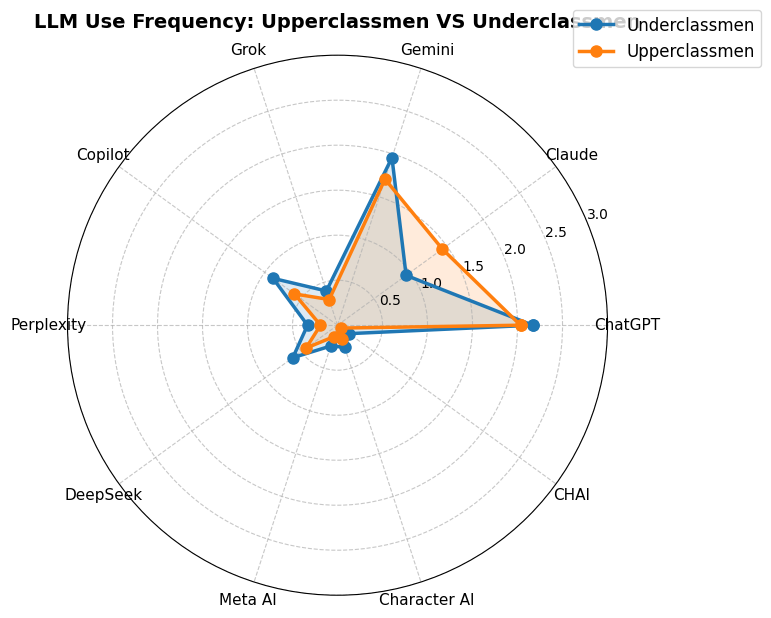

In [ ]:
#I USED BOTH THE LAB 5-6 GUIDE FOR HELP WITH SETTING UP THE 
#SPIDER CHART AS WELL AS CLAUDE FOR HELP MAPPING/REPLACING THE DATA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


data_df = pd.read_csv("data.csv")

#map class standing to upper/underclassmen
standing_map = {'Freshman': 'Underclassmen', 'Sophomore': 'Underclassmen', 'Junior': 'Upperclassmen', 'Senior': 'Upperclassmen'}

data_df['standing_group'] = data_df['What is your current class standing?'].map(standing_map) 

#mapping frequency to numbers
freq_map = {'Never Used': 0, 'Used 1-2 times': 1, 'Use Rarely': 2, 'Use Frequently': 3}

#llm columns from data
llm_cols = [
    'How frequently do you use the following Large Learning Models (LLMs)? [ChatGPT]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Claude]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Gemini]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Grok]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Copilot]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Perplexity]',
    'How frequently do you use the following Large Learning Models (LLMs)? [DeepSeek]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Meta AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [Character AI]',
    'How frequently do you use the following Large Learning Models (LLMs)? [CHAI]'
]

#replace to numeric values 
data_df[llm_cols] = data_df[llm_cols].replace(freq_map)

#mean frequency for each standing group
group_means = data_df.groupby('standing_group')[llm_cols].mean()
group_names = group_means.index.tolist() 

# Set up the radar chart geometry
num_metrics = len(llm_cols)  # Number of metrics (4 in this case)

# Create evenly spaced angles for each axis (in radians)
# endpoint=False means we don't duplicate the starting angle
theta = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)

# Close the polygon by appending the first angle at the end
theta = np.concatenate((theta, [theta[0]]))

# Create the polar plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)  # polar=True creates a circular plot

colors = ['#1f77b4', '#ff7f0e']

for i, group in enumerate(group_names):
    # Get the mean values for this species across all 4 metrics
    values = group_means.loc[group].values

    # Close the polygon by appending the first value at the end
    values = np.concatenate((values, [values[0]]))

    # Plot the line connecting all points
    ax.plot(theta, values, linewidth=2.5, linestyle='solid',
            label=group.capitalize(), color=colors[i], marker='o', markersize=8)

    # Fill the area inside the polygon with transparency
    ax.fill(theta, values, alpha=0.15, color=colors[i])

# Customize the plot
ax.set_xticks(theta[:-1])  # Set tick positions (exclude the duplicate last point)
ax.set_xticklabels(['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot', 'Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI'],
                   fontsize=11)
ax.set_yticklabels(['Used 1-2 times', 'Rarely', 'Frequently'], fontsize=9, color='grey')
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_ylim(0, 3)  # Set radial axis limits to accommodate the data range
ax.grid(True, linestyle='--', alpha=0.7)

# Add legend and title
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('LLM Use Frequency: Upperclassmen VS Underclassmen',
             fontsize=14, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

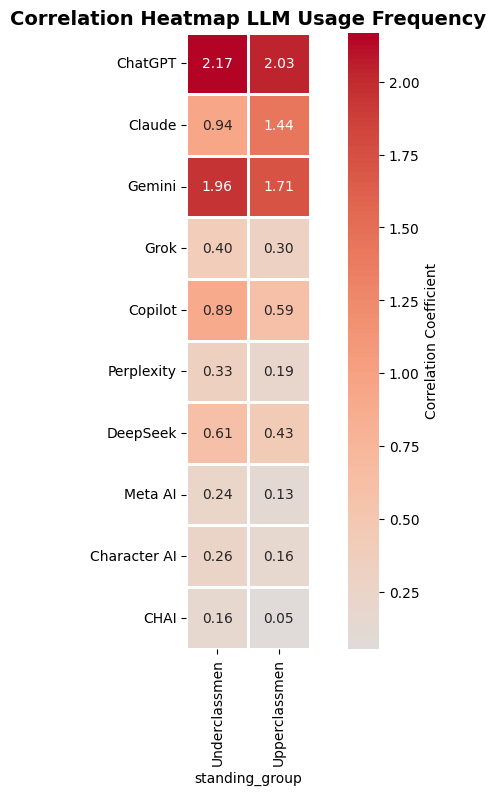

In [2]:
#I USED BOTH THE LAB 5-6 GUIDE TO REFERENCE HOW TO SET UP THE HEATMAP AND ASKED CLAUDE FOR HELP SETTING THE ROWS TO THE LLMS AND 
#THE COLS TO THE CLASS STADING

import seaborn as sns

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
numeric_df = data_df[llm_cols]

#rename columns
llm_names = ['ChatGPT', 'Claude', 'Gemini', 'Grok', 'Copilot','Perplexity', 'DeepSeek', 'Meta AI', 'Character AI', 'CHAI']


#transpose operation, which flips the rows and columns so that
#llm names can be the rows and the class standing can be cols
heat_map = group_means.T
heat_map.index = llm_names



# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(heat_map, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap LLM Usage Frequency', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation